In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv('../data/raw/emotions.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (40000, 3)

Columns: ['tweet_id', 'sentiment', 'content']

First 5 rows:


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [3]:
# Rename columns to standard names
df = df.rename(columns={'content': 'text', 'sentiment': 'emotion'})

# Drop tweet_id — we don't need it
df = df.drop(columns=['tweet_id'])

print("Shape:", df.shape)
print("\nEmotion classes:", df['emotion'].unique())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (40000, 2)

Emotion classes: <ArrowStringArray>
[     'empty',    'sadness', 'enthusiasm',    'neutral',      'worry',
   'surprise',       'love',        'fun',       'hate',  'happiness',
    'boredom',     'relief',      'anger']
Length: 13, dtype: str

Missing values:
 emotion    0
text       0
dtype: int64

Duplicate rows: 91


In [4]:
print(df['emotion'].value_counts())

emotion
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


In [5]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (39909, 2)


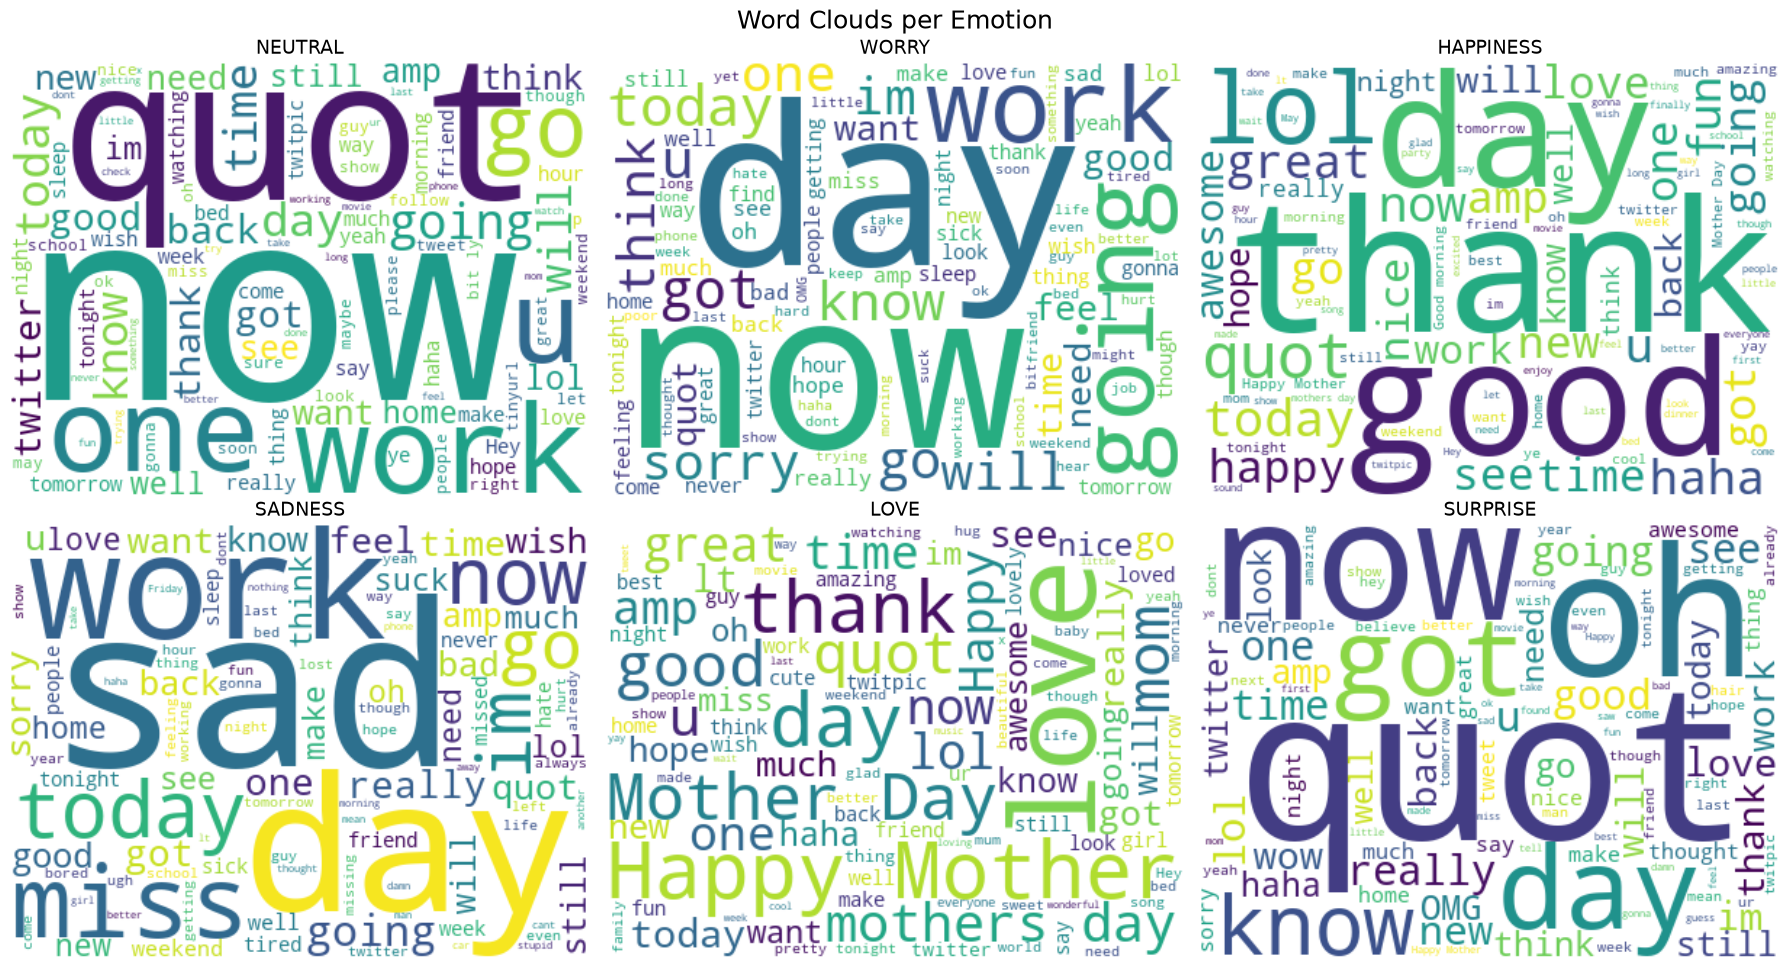

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Pick the top 6 emotions by count to visualize
top_emotions = df['emotion'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, emotion in enumerate(top_emotions):
    text = ' '.join(df[df['emotion'] == emotion]['text'].tolist())
    wc = WordCloud(width=400, height=300, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{emotion.upper()}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Word Clouds per Emotion', fontsize=18)
plt.tight_layout()
plt.show()

In [7]:
# Option A — Keep all classes but the model will be biased toward neutral/worry
# Option B — Keep only emotions with enough samples (recommended for beginners)

# Let's keep emotions with at least 500 samples
min_samples = 500
emotion_counts = df['emotion'].value_counts()
valid_emotions = emotion_counts[emotion_counts >= min_samples].index.tolist()

df_filtered = df[df['emotion'].isin(valid_emotions)].copy()

print("Kept emotions:", valid_emotions)
print("New shape:", df_filtered.shape)
print("\nNew distribution:\n", df_filtered['emotion'].value_counts())

Kept emotions: ['neutral', 'worry', 'happiness', 'sadness', 'love', 'surprise', 'fun', 'relief', 'hate', 'empty', 'enthusiasm']
New shape: (39620, 2)

New distribution:
 emotion
neutral       8617
worry         8452
happiness     5194
sadness       5160
love          3801
surprise      2187
fun           1776
relief        1524
hate          1323
empty          827
enthusiasm     759
Name: count, dtype: int64


In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+\s*', '', text)                # remove @mentions FIRST
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)          # remove URLs
    text = re.sub(r'#\w+', '', text)                              # remove hashtags
    text = re.sub(r'&quot;|&amp;|&lt;|&gt;|&apos;', '', text)    # remove HTML artifacts
    text = re.sub(r'\brt\b', '', text)                            # remove retweet tag
    text = re.sub(r'(.)\1{2,}', r'\1', text)                     # fix repeated chars
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r'[^a-z\s]', ' ', text)                        # replace punctuation with space
    text = re.sub(r'\s+', ' ', text).strip()                      # remove extra whitespace
    return text

def remove_stopwords(text):
    tokens = text.split()
    filtered = [w for w in tokens if w not in stop_words and len(w) > 1]  # also remove single chars
    return ' '.join(filtered)

def lemmatize_text(text):
    tokens = text.split()
    lemmatized = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(lemmatized)

def preprocess(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

print("✅ Preprocessing functions ready!")

✅ Preprocessing functions ready!


In [16]:
df_filtered['clean_text'] = df_filtered['text'].apply(preprocess)

print("Done! Sample output:\n")
for i in range(3):
    print(f"Original : {df_filtered['text'].iloc[i]}")
    print(f"Cleaned  : {df_filtered['clean_text'].iloc[i]}")
    print()

Done! Sample output:

Original : @tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[
Cleaned  : know listenin bad habit earlier started freakin part

Original : Layin n bed with a headache  ughhhh...waitin on your call...
Cleaned  : layin bed headache ugh waitin call

Original : Funeral ceremony...gloomy friday...
Cleaned  : funeral ceremony gloomy friday



In [10]:
# Some tweets may become empty after cleaning (e.g. only had @mentions and URLs)
empty_mask = df_filtered['clean_text'].str.strip() == ''
print(f"Empty rows after cleaning: {empty_mask.sum()}")

# Drop them
df_filtered = df_filtered[~empty_mask].reset_index(drop=True)
print(f"Final shape: {df_filtered.shape}")

Empty rows after cleaning: 25
Final shape: (39595, 3)


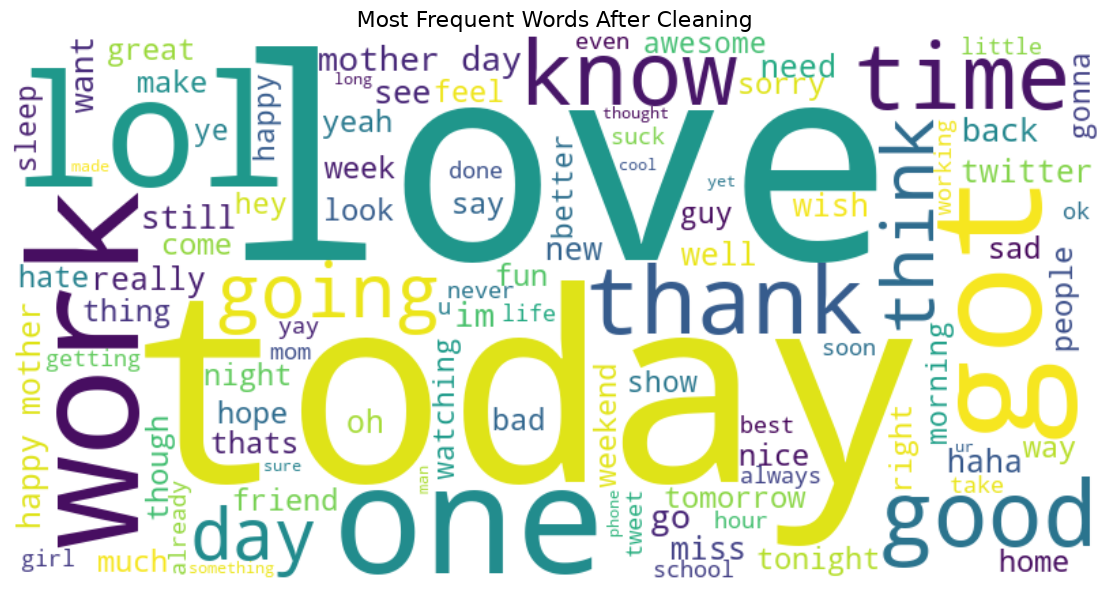

In [11]:
from wordcloud import WordCloud

all_text = ' '.join(df_filtered['clean_text'].tolist())
wc = WordCloud(width=800, height=400, background_color='white',
               max_words=100, colormap='viridis').generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words After Cleaning', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
df_filtered.to_csv('../data/processed/emotions_cleaned.csv', index=False)
print("✅ Cleaned dataset saved to data/processed/emotions_cleaned.csv")
print(f"Total rows: {len(df_filtered)}")

✅ Cleaned dataset saved to data/processed/emotions_cleaned.csv
Total rows: 39595


In [18]:
X = df_filtered['clean_text']
y = df_filtered['emotion']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nEmotion distribution:\n", y.value_counts())

X shape: (39595,)
y shape: (39595,)

Emotion distribution:
 emotion
neutral       8606
worry         8448
happiness     5193
sadness       5158
love          3800
surprise      2184
fun           1776
relief        1524
hate          1321
empty          826
enthusiasm     759
Name: count, dtype: int64


In [19]:
tfidf = TfidfVectorizer(
    max_features=5000,      # keep top 5000 words
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # ignore words appearing in less than 2 tweets
    max_df=0.95             # ignore words appearing in more than 95% of tweets
)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))
print("\nSample features:", list(tfidf.vocabulary_.keys())[:20])

TF-IDF matrix shape: (39595, 5000)
Vocabulary size: 5000

Sample features: ['know', 'listenin', 'bad', 'habit', 'earlier', 'started', 'freakin', 'part', 'bed', 'headache', 'ugh', 'waitin', 'call', 'funeral', 'gloomy', 'friday', 'want', 'hang', 'friend', 'soon']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures each emotion is proportionally represented
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (31676, 5000)
X_test shape: (7919, 5000)
y_train shape: (31676,)
y_test shape: (7919,)


In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("✅ Logistic Regression trained!")
print("Accuracy:", round(accuracy_score(y_test, lr_preds), 4))

✅ Logistic Regression trained!
Accuracy: 0.3495


In [23]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("✅ Naive Bayes trained!")
print("Accuracy:", round(accuracy_score(y_test, lr_preds), 4))

✅ Naive Bayes trained!
Accuracy: 0.3495


In [25]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print("✅ Linear SVM trained!")
print("Accuracy:", round(accuracy_score(y_test, lr_preds), 4))

✅ Linear SVM trained!
Accuracy: 0.3495


                 Model  Accuracy
0  Logistic Regression    0.3495
1           Linear SVM    0.3226
2          Naive Bayes    0.3207


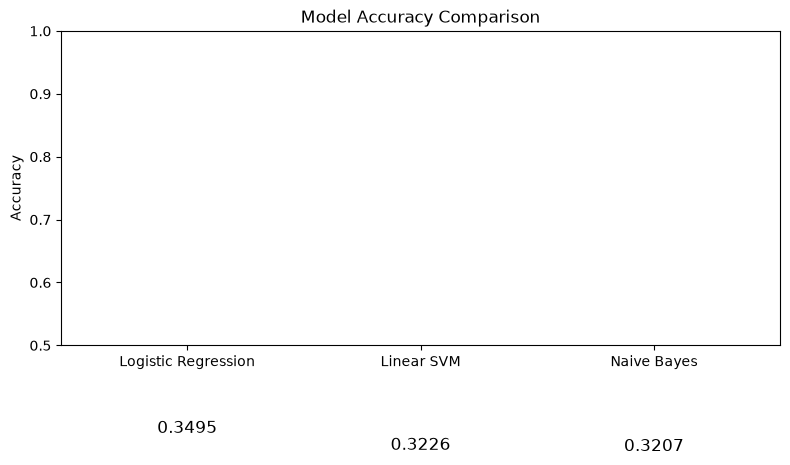

In [27]:
accuracies = [
    round(accuracy_score(y_test, lr_preds), 4),
    round(accuracy_score(y_test, nb_preds), 4),
    round(accuracy_score(y_test, svm_preds), 4)
]

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': accuracies
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=['#2ecc71', '#3498db', '#9b59b6'])
plt.title('Model Accuracy Comparison')
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')

# Add value labels on top of bars
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(acc), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.utils import resample

# Oversample minority classes to match the majority class
majority_count = df_filtered['emotion'].value_counts().max()

balanced_dfs = []
for emotion in df_filtered['emotion'].unique():
    subset = df_filtered[df_filtered['emotion'] == emotion]
    oversampled = resample(subset, 
                          replace=True,
                          n_samples=majority_count,
                          random_state=42)
    balanced_dfs.append(oversampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
print("Balanced shape:", df_balanced.shape)
print("\nNew distribution:\n", df_balanced['emotion'].value_counts())

Balanced shape: (94666, 3)

New distribution:
 emotion
empty         8606
sadness       8606
enthusiasm    8606
neutral       8606
worry         8606
surprise      8606
love          8606
fun           8606
hate          8606
happiness     8606
relief        8606
Name: count, dtype: int64


In [29]:
X_bal = df_balanced['clean_text']
y_bal = df_balanced['emotion']

tfidf_bal = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf_bal = tfidf_bal.fit_transform(X_bal)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (75732, 5000)
X_test: (18934, 5000)


In [30]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = round(accuracy_score(y_test, lr_preds), 4)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_acc = round(accuracy_score(y_test, nb_preds), 4)

# Linear SVM
svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_acc = round(accuracy_score(y_test, svm_preds), 4)

print(f"Logistic Regression : {lr_acc}")
print(f"Naive Bayes         : {nb_acc}")
print(f"Linear SVM          : {svm_acc}")

Logistic Regression : 0.5581
Naive Bayes         : 0.5013
Linear SVM          : 0.6136


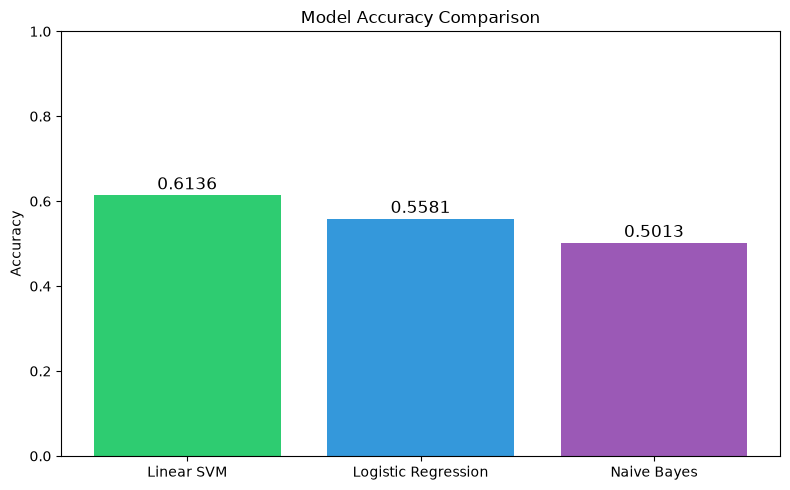

In [32]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [lr_acc, nb_acc, svm_acc]
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=['#2ecc71', '#3498db', '#9b59b6'])
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(acc), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [33]:
# Group similar emotions together
emotion_map = {
    'happiness': 'joy',
    'fun':       'joy',
    'enthusiasm':'joy',
    'love':      'love',
    'sadness':   'sadness',
    'worry':     'worry',
    'neutral':   'neutral',
    'surprise':  'surprise',
    'relief':    'neutral',
    'hate':      'anger',
    'empty':     'sadness'
}

df_filtered['emotion_grouped'] = df_filtered['emotion'].map(emotion_map)

print("New emotion distribution:\n")
print(df_filtered['emotion_grouped'].value_counts())

New emotion distribution:

emotion_grouped
neutral     10130
worry        8448
joy          7728
sadness      5984
love         3800
surprise     2184
anger        1321
Name: count, dtype: int64


In [35]:
# Balance
majority_count = df_filtered['emotion_grouped'].value_counts().max()
balanced_dfs = []
for emotion in df_filtered['emotion_grouped'].unique():
    subset = df_filtered[df_filtered['emotion_grouped'] == emotion]
    oversampled = resample(subset, replace=True, n_samples=majority_count, random_state=42)
    balanced_dfs.append(oversampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)

# Vectorize
X_bal = df_balanced['clean_text']
y_bal = df_balanced['emotion_grouped']

tfidf_bal = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf_bal = tfidf_bal.fit_transform(X_bal)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

# Train SVM (our best model)
svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print("New Accuracy:", round(accuracy_score(y_test, svm_preds), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_preds))

New Accuracy: 0.5827

Classification Report:

              precision    recall  f1-score   support

       anger       0.79      0.94      0.86      2026
         joy       0.52      0.48      0.50      2026
        love       0.64      0.69      0.66      2026
     neutral       0.42      0.39      0.40      2026
     sadness       0.53      0.50      0.52      2026
    surprise       0.63      0.69      0.66      2026
       worry       0.47      0.39      0.43      2026

    accuracy                           0.58     14182
   macro avg       0.57      0.58      0.57     14182
weighted avg       0.57      0.58      0.57     14182



In [36]:
emotion_map = {
    'happiness':  'joy',
    'fun':        'joy',
    'enthusiasm': 'joy',
    'love':       'love',
    'sadness':    'sadness',
    'empty':      'sadness',
    'worry':      'neutral',   # worry → neutral (too similar)
    'neutral':    'neutral',
    'relief':     'neutral',
    'surprise':   'surprise',
    'hate':       'anger',
}

df_filtered['emotion_grouped'] = df_filtered['emotion'].map(emotion_map)
print("New distribution:\n", df_filtered['emotion_grouped'].value_counts())

New distribution:
 emotion_grouped
neutral     18578
joy          7728
sadness      5984
love         3800
surprise     2184
anger        1321
Name: count, dtype: int64


In [37]:
majority_count = df_filtered['emotion_grouped'].value_counts().max()
balanced_dfs = []
for emotion in df_filtered['emotion_grouped'].unique():
    subset = df_filtered[df_filtered['emotion_grouped'] == emotion]
    oversampled = resample(subset, replace=True, n_samples=majority_count, random_state=42)
    balanced_dfs.append(oversampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)

X_bal = df_balanced['clean_text']
y_bal = df_balanced['emotion_grouped']

# Better TF-IDF settings
tfidf_bal = TfidfVectorizer(
    max_features=10000,     # increased from 5000
    ngram_range=(1, 3),     # added trigrams
    min_df=2,
    max_df=0.90,            # stricter cutoff
    sublinear_tf=True       # apply log normalization
)
X_tfidf_bal = tfidf_bal.fit_transform(X_bal)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (89174, 10000)
Test: (22294, 10000)


In [38]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Tuned SVM
svm_tuned = LinearSVC(
    C=0.5,              # regularization
    max_iter=2000,
    random_state=42
)

# Wrap with calibration so we can get confidence scores later
svm_calibrated = CalibratedClassifierCV(svm_tuned, cv=3)
svm_calibrated.fit(X_train, y_train)
svm_preds = svm_calibrated.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, svm_preds), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_preds))

Accuracy: 0.6943

Classification Report:

              precision    recall  f1-score   support

       anger       0.91      0.96      0.93      3715
         joy       0.60      0.58      0.59      3715
        love       0.72      0.76      0.74      3716
     neutral       0.51      0.42      0.46      3716
     sadness       0.65      0.64      0.64      3716
    surprise       0.73      0.80      0.76      3716

    accuracy                           0.69     22294
   macro avg       0.69      0.69      0.69     22294
weighted avg       0.69      0.69      0.69     22294



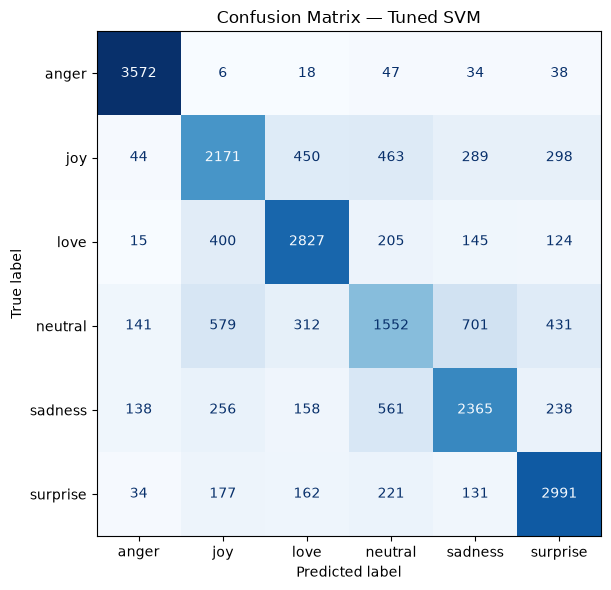

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, svm_preds, labels=svm_calibrated.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_calibrated.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — Tuned SVM')
plt.tight_layout()
plt.show()

In [40]:
# Drop neutral emotion
df_no_neutral = df_filtered[df_filtered['emotion_grouped'] != 'neutral'].copy()
print("Shape after dropping neutral:", df_no_neutral.shape)
print("\nDistribution:\n", df_no_neutral['emotion_grouped'].value_counts())

Shape after dropping neutral: (21017, 4)

Distribution:
 emotion_grouped
joy         7728
sadness     5984
love        3800
surprise    2184
anger       1321
Name: count, dtype: int64


In [41]:
majority_count = df_no_neutral['emotion_grouped'].value_counts().max()
balanced_dfs = []
for emotion in df_no_neutral['emotion_grouped'].unique():
    subset = df_no_neutral[df_no_neutral['emotion_grouped'] == emotion]
    oversampled = resample(subset, replace=True, n_samples=majority_count, random_state=42)
    balanced_dfs.append(oversampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
print("Balanced shape:", df_balanced.shape)
print("\nBalanced distribution:\n", df_balanced['emotion_grouped'].value_counts())

Balanced shape: (38640, 4)

Balanced distribution:
 emotion_grouped
sadness     7728
joy         7728
surprise    7728
love        7728
anger       7728
Name: count, dtype: int64


In [42]:
X_bal = df_balanced['clean_text']
y_bal = df_balanced['emotion_grouped']

tfidf_bal = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X_tfidf_bal = tfidf_bal.fit_transform(X_bal)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (30912, 10000)
Test: (7728, 10000)


In [43]:
svm_tuned = LinearSVC(C=0.5, max_iter=2000, random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_tuned, cv=3)
svm_calibrated.fit(X_train, y_train)
svm_preds = svm_calibrated.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, svm_preds), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_preds))

Accuracy: 0.7374

Classification Report:

              precision    recall  f1-score   support

       anger       0.89      0.92      0.90      1546
         joy       0.64      0.61      0.63      1545
        love       0.72      0.73      0.72      1546
     sadness       0.72      0.69      0.71      1546
    surprise       0.72      0.73      0.72      1545

    accuracy                           0.74      7728
   macro avg       0.74      0.74      0.74      7728
weighted avg       0.74      0.74      0.74      7728



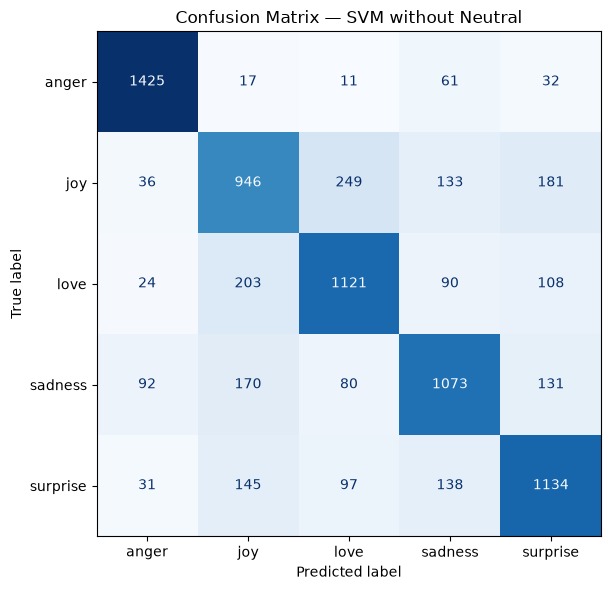

In [45]:
cm = confusion_matrix(y_test, svm_preds, labels=svm_calibrated.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_calibrated.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — SVM without Neutral')
plt.tight_layout()
plt.show()

In [46]:
import pickle
import os

# Save the trained SVM model
with open('../models/emotion_model.pkl', 'wb') as f:
    pickle.dump(svm_calibrated, f)

# Save the TF-IDF vectorizer
with open('../models/vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_bal, f)

# Save the emotion labels
emotion_labels = list(svm_calibrated.classes_)
with open('../models/labels.pkl', 'wb') as f:
    pickle.dump(emotion_labels, f)

print("✅ Model saved!")
print("✅ Vectorizer saved!")
print("✅ Labels saved:", emotion_labels)
print("\nFiles in models folder:")
print(os.listdir('../models'))

✅ Model saved!
✅ Vectorizer saved!
✅ Labels saved: ['anger', 'joy', 'love', 'sadness', 'surprise']

Files in models folder:
['emotion_model.pkl', 'labels.pkl', 'vectorizer.pkl']
